In [2]:
import os, glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

In [3]:
# Import data file
data_directory = 'C:/Users/mvmigem/Documents/data/project_2/raw/'
dir_list = glob.glob(data_directory+'sub-*/behav/*.csv')

In [4]:
# Put all data in big df
df_list = []
for i in range(len(dir_list)):
    behav_dat = pd.read_csv(dir_list[i])
    df_list.append(behav_dat)

big_df = pd.concat(df_list,ignore_index=True)
# Trial level instead of stimulus level
sub_df = big_df[big_df['sequence'] == 1]
# Target trials only
targets_df = sub_df[sub_df['target_trials'] == 1]

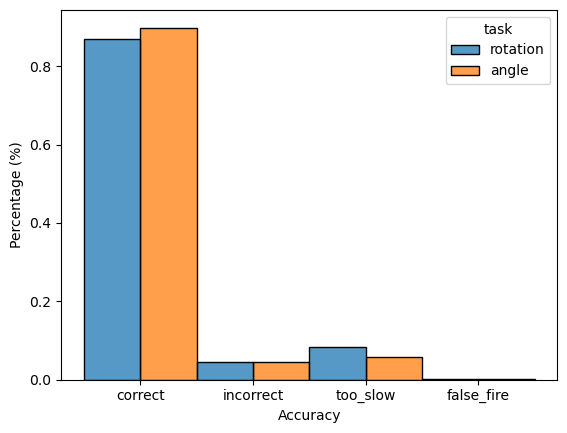

In [5]:
# Create the plot
sns.histplot(data=targets_df, x='accuracy', hue='task', stat='proportion',common_norm = False, multiple='dodge')

plt.xlabel('Accuracy')
plt.ylabel('Percentage (%)')
plt.show()

In [6]:
# function for the calculation of SDT measures
# Otherwise, infer signal/noise from accuracy:
sub_df['is_signal'] = sub_df['accuracy'].isin(['correct', 'miss','too_slow'])  # Assume hits/misses = signal trials
sub_df['is_noise'] = sub_df['accuracy'].isin(['false_fire', 'correct_nogo'])

def calculate_dprime(group):
    # Calculate Hit Rate (HR)
    hits = (group['accuracy'] == 'correct').sum()
    signal_trials = group['is_signal'].sum()
    hr = (hits + 0.5) / (signal_trials + 1)
    acc = hits / signal_trials
    norm_hr = stats.norm.ppf(hr)

    # Calculate False Alarm Rate (FAR)
    false_alarms = (group['accuracy'] == 'false_fire').sum()
    noise_trials = group['is_noise'].sum()
    far = (false_alarms + 0.5) / (noise_trials +1)
    norm_far = stats.norm.ppf(far)
    
    # Calculate d' (Z-scores) and beta 
    dprime = norm_hr - norm_far
    beta = np.exp((norm_far**2 - norm_hr**2) / 2)

    return pd.Series({
        'hits': hits,
        'misses': (group['accuracy'] == 'miss').sum(),
        'too_slow': (group['accuracy'] == 'too_slow').sum(),
        'false_alarms': false_alarms,
        'signal_trials': signal_trials,
        'noise_trials': noise_trials,
        'hit_rate': hr,
        'accuracy': acc,
        'false_alarm_rate': far,
        'dprime': dprime,
        'beta':beta
    })


C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\4203072398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['is_signal'] = sub_df['accuracy'].isin(['correct', 'miss','too_slow'])  # Assume hits/misses = signal trials
C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\4203072398.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['is_noise'] = sub_df['accuracy'].isin(['false_fire', 'correct_nogo'])


In [7]:
# Remove participants that have accuracy lower than 3std below mean
acc_results = sub_df.groupby(['participant']).apply(calculate_dprime).reset_index()
threshold = acc_results.accuracy.mean() - acc_results.accuracy.std() *3
ex_pp = acc_results[acc_results['accuracy'] <= threshold]['participant'].to_numpy()
sub_df = sub_df[~sub_df['participant'].isin(ex_pp)]
targets_df = targets_df[~targets_df['participant'].isin(ex_pp)]

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\1604200356.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = sub_df.groupby(['participant']).apply(calculate_dprime).reset_index()


In [8]:
acc_results.accuracy.std()

np.float64(0.10396947920818833)

In [9]:
# Subselecting on particpant, block and task for the exclusion of 'practice' blocks
# Group by participant and condition, then apply d' calculation
acc_results = sub_df.groupby(['participant','block','task']).apply(calculate_dprime).reset_index()
# Find the first blocks with an acc above chance level (.75) per task per participant
def filter_first_accurate_blocks(df, accuracy_threshold=0.75):
    """
    Filter blocks to find the first block for each task per participant 
    that meets the accuracy threshold
    """
    # Sort by participant, task, and block to ensure proper ordering
    df_sorted = df.sort_values(['participant', 'task', 'block'])
    
    # Create a result dataframe
    result_rows = []
    invalid_rows = []
    # Group by participant and task
    for (participant, task), group in df_sorted.groupby(['participant', 'task']):
        # Filter blocks for this participant-task combination
        task_blocks = group.sort_values('block')
        
        # Find the first block with accuracy >= threshold
        first_valid_block = None
        for _, row in task_blocks.iterrows():
            if row['accuracy'] > accuracy_threshold:
                first_valid_block = row
                break
            else:
                invalid_rows.append(row)
        
        # If found, add to results
        if first_valid_block is not None:
            result_rows.append(first_valid_block)

    
    # Create the filtered dataframe
    result_df = pd.DataFrame(result_rows)
    invalid_df = pd.DataFrame(invalid_rows)
    
    return result_df,invalid_df


valid_df,invalid_df = filter_first_accurate_blocks(acc_results)

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\2132617066.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = sub_df.groupby(['participant','block','task']).apply(calculate_dprime).reset_index()


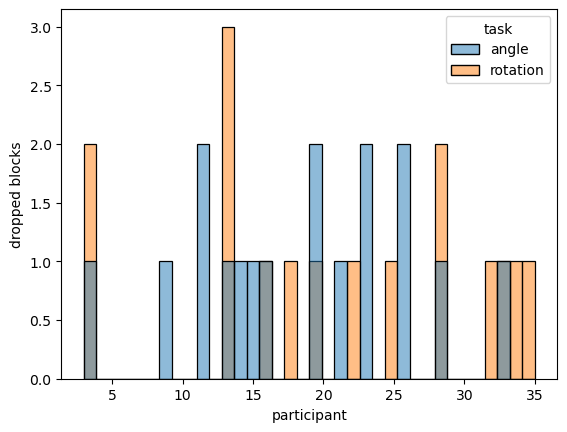

In [10]:
# Create the plot
sns.histplot(data=invalid_df, x='participant', hue= 'task', stat='count',common_norm = False, bins = 36)
# sns.histplot(data=invalid_df, x='participant', stat='count',common_norm = False, bins = 36)
# plt.xlabel('')
plt.ylabel('dropped blocks')
plt.show()

In [11]:
# These dataframes give an overview of the the amount of excluded blocks
# task_participant_counts = invalid_df.groupby(['task']).size().reset_index(name='count')
task_participant_counts = invalid_df.groupby(['participant','task']).size().reset_index(name='count')

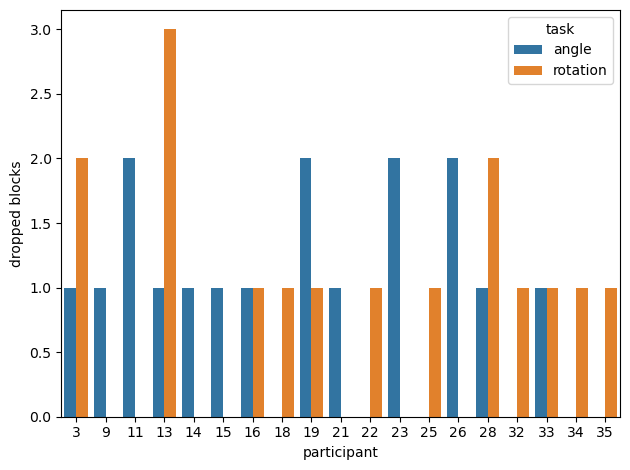

In [12]:
ax = sns.barplot(data=task_participant_counts, y = 'count', x = 'participant',hue= 'task')
plt.ylabel('dropped blocks')
plt.tight_layout()
plt.show()

In [25]:
# Actually exclude
cutoff_list = list(zip(invalid_df['participant'],invalid_df['block']))
cuttoff_df = sub_df[~sub_df.set_index(['participant', 'block']).index.isin(cutoff_list)]

acc_results = cuttoff_df.groupby(['participant','task','angle_prediction','rotation_prediction']).apply(calculate_dprime).reset_index()

acc_results['attended_feature'] = np.where(acc_results['task']== 'angle',
                                            acc_results['angle_prediction'],
                                            acc_results['rotation_prediction'])

acc_results['unattended_feature'] = np.where(acc_results['task']== 'angle',
                                              acc_results['rotation_prediction'],
                                              acc_results['angle_prediction'])

acc_results = acc_results.rename(columns={'task':'feature'})

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\2191572174.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc_results = cuttoff_df.groupby(['participant','task','angle_prediction','rotation_prediction']).apply(calculate_dprime).reset_index()


In [19]:
# Save the behaviour dataframe
destination_folder = r"C:\Users\mvmigem\Documents\data\project_2\compiled_data/"
acc_results.to_csv(destination_folder + "behaviour_acc.csv")

In [ ]:
# Simple plots
# fig, axs = plt.subplots(1,2,figsize=(10, 4))
line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]

acc_results = cuttoff_df.groupby(['participant','task','angle_prediction','rotation_prediction']).apply(calculate_dprime).reset_index()
sns.catplot(data= acc_results, y = 'accuracy', x = 'task', hue='rotation_prediction', kind= 'box', col='angle_prediction')

plt.show()

C:\Users\mvmigem\AppData\Local\Temp\ipykernel_21160\1552532568.py:5: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  g = sns.catplot(data= acc_results, y = 'dprime', x = 'attended_feature',


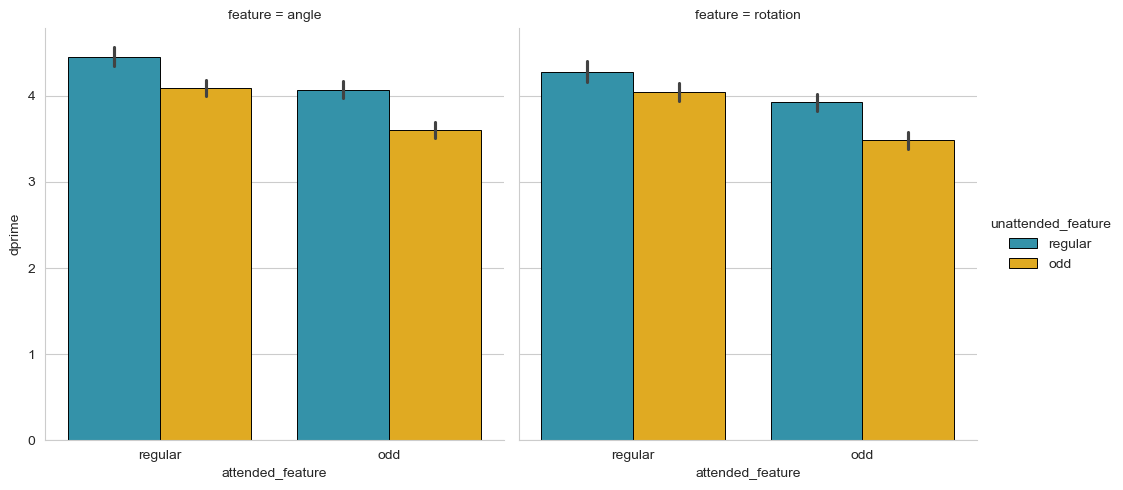

In [27]:
sns.set_style('whitegrid')

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= acc_results, y = 'dprime', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours1)
# g.set(ylim= .7)

plt.show()

In [ ]:
sns.set_style('whitegrid')

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= acc_results, y = 'dprime', x = 'rotation_prediction',
            hue = 'angle_prediction',# col = 'task',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            # col_order= ['regular', 'odd'],
            palette=line_colours1)
# g.set(ylim= .7)

plt.show()

In [ ]:
# Reaction times
# Only correct trials
rt_df = targets_df[targets_df['accuracy']== 'correct']
# Start with group level participant exclusion (difference of more than 3 std fromn mean)
rt_results = rt_df.groupby(['participant'])['rt'].mean().reset_index()
grand_mean_rt = rt_results['rt'].mean()
three_std = 3 * rt_results['rt'].std()
rt_ex_pp = rt_results[~rt_results['rt'].between(grand_mean_rt - three_std, grand_mean_rt + three_std)]['participant'].values # Turns out none were excluded
# Apply
rt_df = rt_df[~rt_df['participant'].isin(rt_ex_pp)]

In [ ]:
# Next the exclusion of within participant outlier trials
rt_results = rt_df.groupby(['participant'])['rt'].agg(['mean','std']).reset_index()
# Merge stats back to original DataFrame
rt_df = rt_df.merge(rt_results, on='participant')
# Filter trials within 3 standard deviations
outlier_mask = (
    (rt_df['rt'] >= rt_df['mean'] - 3 * rt_df['std']) &
    (rt_df['rt'] <= rt_df['mean'] + 3 * rt_df['std'])
)
# Count outliers per subject
trials_removed = rt_df[~outlier_mask].groupby('participant').size().rename('trials_removed')
# Apply
rt_df = rt_df[outlier_mask]


In [ ]:
# Create rt dataset
rt_results = rt_df.groupby(['participant','task','angle_prediction','rotation_prediction'])['rt'].mean().reset_index()

In [ ]:
# Save the behaviour dataframe
destination_folder = r"C:\Users\mvmigem\Documents\data\project_2\compiled_data/"
rt_results.to_csv(destination_folder + "behaviour_rt.csv")

In [ ]:

sns.set_style('whitegrid')

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= rt_results, y = 'rt', x = 'rotation_prediction',
            hue = 'angle_prediction',# col = 'task',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7,
            hue_order= ['regular', 'odd'],
            # col_order= ['regular', 'odd'],
            palette=line_colours1)
# g.set(ylim= .7)

plt.show()

In [ ]:
# Demographics
demo_df = big_df[big_df['trial'] == 1][big_df['sequence'] == 1]

In [ ]:
demo_df['handed'].value_counts()

In [ ]:
demo_df['age'].agg(['mean','std'])